In [22]:
import xarray as xr
import numpy as np
import sys
sys.path.append("/home/jupyter-vincent2/vincent/process_profiles/noteboooks_2026/functions")
from create_rec_datasets import r_analysis_df
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import pandas as pd
plt.rcParams.update({'font.size': 20})

In [5]:
### Bathy
ncfile_etopo1 = "/media/disk2/vincent/process_profiles/data/external_supports/GEBCO_ker_large.nc"
ds_topo = xr.open_dataset(ncfile_etopo1)
elevation = ds_topo.elevation[::10,::10]
### Fronts
ds_front = xr.open_dataset("/media/disk2/vincent/process_profiles/data/external_supports/62985.nc")
### CMA
ds_CMA = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_anom.nc")
ds_CMA_clim = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/CMA_clim.nc")
### G
ds_G = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_anom.nc")
ds_G_clim = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_clim.nc")
### CL  
ds_CL = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_anom.nc")
ds_CL_clim = xr.open_dataset("/home/jupyter-vincent2/vincent/process_profiles/data/processed_2026/GLORYS_CL_clim.nc")

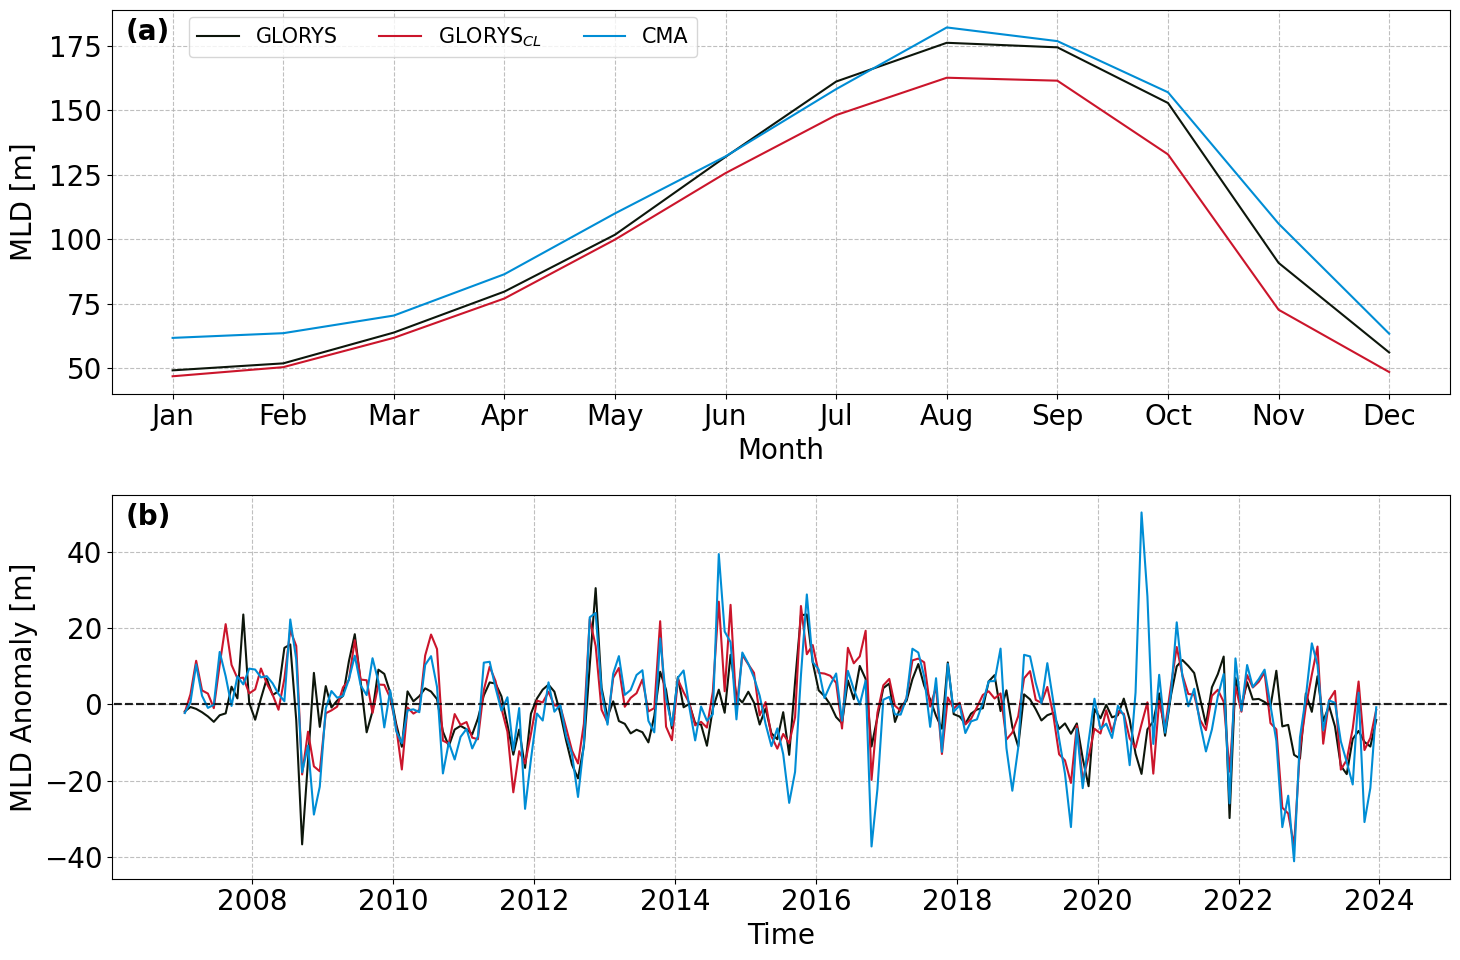

In [60]:
datasets = {'G': ds_G, 'CL': ds_CL, 'CMA': ds_CMA}
datasets_clim = {'G': ds_G_clim, 'CL': ds_CL_clim, 'CMA': ds_CMA_clim}
colors = {"G": "#0D160B", "CL": "#CB152B", "CMA": "#008DD5"}
labels = {"G": "GLORYS", "CL": "GLORYS$_{CL}$", "CMA": "CMA"}
legend_fs = 15

fig,ax = plt.subplots(2,1,figsize=(15,10),tight_layout=True)
for clim,anom,color in zip(datasets_clim.items(), datasets.items(), colors.keys()):
    ax[0].plot(clim[1].month, clim[1].mld.mean(dim=["latitude","longitude"]), label=labels[clim[0]], color=colors[color])
    ax[1].plot(anom[1].time, anom[1].mld.mean(dim=["latitude","longitude"]), label=labels[anom[0]], color=colors[color])
    ax[1].hlines(0, ds_CMA.time.min()-pd.Timedelta(days=365), ds_CMA.time.max()+pd.Timedelta(days=365), color="k", linestyle="--", alpha=0.5)
    ax[1].set_xlim(pd.to_datetime("2006-01-02"), pd.to_datetime("2025-01-01"))
### Fixing axes
ax[0].set_xticks(np.arange(1,13))
ax[0].set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax[0].set_xlabel("Month")
ax[0].set_ylabel("MLD [m]")
ax[0].legend(ncol=3,fontsize=legend_fs,loc="upper left", bbox_to_anchor=(0.05, 1.01))
ax[1].set_xlabel("Time")
ax[1].set_ylabel("MLD Anomaly [m]")


for j,a in enumerate(ax):
    a.grid(True, linestyle="--", alpha=0.8)
    a.text(
        0.01, 0.98, f"({chr(98 + j-1)})",
        transform=a.transAxes,
        ha="left", va="top",
        fontsize=20, fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2),
    )
fig.align_ylabels()

fig.savefig("/home/jupyter-vincent2/vincent/process_profiles/figures_2026/Figure_3_seasonal_cycle.png", dpi=300, bbox_inches='tight')